In [5]:
# === Backtesting Engine: 2021 - 2023 (Monthly Rebalance, 3-Month Rolling Window) ===

import yfinance as yf
import pennylane as qml
from pennylane import numpy as pnp
import numpy as np
import pandas as pd
import scipy.linalg as la
import matplotlib.pyplot as plt
from itertools import combinations
import warnings

warnings.filterwarnings('ignore')

print("Starting Setup for Backtesting (2021-2023)...")


Starting Setup for Backtesting (2021-2023)...


In [6]:
# 1. Konfigurasi
tickers = ['DUK', 'MSFT', 'CVX', 'TSLA']
K = 2
penalty_A = 5.0
max_depth = 4                # Kedalaman maksimum ansatz (adaptive)
maxiter   = 100              # Iterasi SPSA per depth-level

# Parameter Kalender
initial_capital = 100_000_000.0
# Di bursa, 1 bulan ~ 21 hari perdagangan, 3 bulan ~ 63 hari perdagangan
lookback_days = 63 
rebalance_days = 21 

# 2. Download Data
data = yf.download(tickers, start="2020-09-01", end="2024-01-01", progress=False)['Close']
data = data.dropna()
data_clean = data.sort_index()

print(f"Data Berhasil Diunduh. Total hari observasi: {len(data_clean)}")


Data Berhasil Diunduh. Total hari observasi: 838


In [7]:
# Helper Function: Extract QMI, Bias, Payoffs, and Build Hamiltonian (mirip cell sebelumnya)
def compute_endogenous_lambda(log_returns, tickers):
    mu_annual = log_returns[tickers].mean() * 252
    sigma_annual = log_returns[tickers].std() * np.sqrt(252)
    mu_avg = abs(mu_annual).mean()
    sigma_avg = sigma_annual.mean()
    if np.isnan(mu_avg) or np.isnan(sigma_avg) or (mu_avg + sigma_avg) == 0:
        return 0.5 
    # Sigmoid / Logistic function based on Sharpe Ratio
    Z = mu_avg / sigma_avg
    return 1.0 / (1.0 + np.exp(Z))

def build_hamiltonian(h, J, n_assets, K=2, penalty_A=5.0):
    coeffs = []
    obs = []
    
    # H_cost
    for i in range(n_assets):
        if abs(h[i]) > 1e-10:
            coeffs.append(float(h[i]))
            obs.append(qml.PauliZ(i))
            
    for i in range(n_assets):
        for j in range(i + 1, n_assets):
            if abs(J[i, j]) > 1e-10:
                coeffs.append(float(J[i, j]))
                obs.append(qml.PauliZ(i) @ qml.PauliZ(j))
                
    # H_constraint (Penalty to ensure exactly K assets are chosen)
    coeffs.append(float(penalty_A))
    obs.append(qml.Identity(0)) 
    
    for pair in combinations(range(n_assets), 2):
        coeffs.append(float(penalty_A / 2))
        obs.append(qml.PauliZ(pair[0]) @ qml.PauliZ(pair[1]))
        
    return qml.Hamiltonian(coeffs, obs)

def run_vqe_adaptive(H, n_qubits, K=2, max_depth=4,
                     maxiter=100, max_total_iter=2000,
                     batch_size=25, conv_window=4, conv_tol=1e-4,
                     seed=42):
    """
    Menjalankan VQE dengan dua mekanisme adaptif:

    (A) Adaptive SPSA Iterations (konvergensi otomatis):
        - SPSA dijalankan dalam batch kecil (``batch_size`` iterasi per batch).
        - Setelah setiap batch, evaluasi energi disimpan ke ``energy_history``.
        - Konvergensi terdeteksi jika relative change energi pada jendela
          ``conv_window`` batch terakhir di bawah ``conv_tol``:
              |E_{t-w} - E_t| / (|E_{t-w}| + eps) < conv_tol
        - Berhenti otomatis saat konvergen atau ``max_total_iter`` tercapai.
        - ``maxiter`` hanya digunakan sebagai batas bawah (minimal iterasi
          awal sebelum cek konvergensi dimulai).

    (B) Adaptive Layer Selection (sesuai flowchart Bab-3.tex):
        - Mulai dari depth=1; setelah SPSA konvergen, evaluasi E_L.
        - Tambah layer jika E_L < E_{L-1} (penurunan energi signifikan).
        - Berhenti jika energi tidak turun atau ``max_depth`` tercapai.

    Ansatz: EfficientSU(2) manual → lapisan RY-RZ dengan entanglement CNOT ring.
    Optimizer: SPSA dengan parameter standar (a=0.1, c=0.1, alpha=0.602, gamma=0.101).
    """
    dev = qml.device("default.qubit", wires=n_qubits)
    rng = np.random.default_rng(seed)

    def make_circuit(depth):
        @qml.qnode(dev)
        def cost_circuit(params):
            w = params.reshape((depth + 1, n_qubits, 2))
            for layer in range(depth + 1):
                for q in range(n_qubits):
                    qml.RY(w[layer, q, 0], wires=q)
                    qml.RZ(w[layer, q, 1], wires=q)
                if layer < depth:
                    for q in range(n_qubits - 1):
                        qml.CNOT(wires=[q, q + 1])
                    qml.CNOT(wires=[n_qubits - 1, 0])
            return qml.expval(H)

        @qml.qnode(dev)
        def prob_circuit(params):
            w = params.reshape((depth + 1, n_qubits, 2))
            for layer in range(depth + 1):
                for q in range(n_qubits):
                    qml.RY(w[layer, q, 0], wires=q)
                    qml.RZ(w[layer, q, 1], wires=q)
                if layer < depth:
                    for q in range(n_qubits - 1):
                        qml.CNOT(wires=[q, q + 1])
                    qml.CNOT(wires=[n_qubits - 1, 0])
            return qml.probs(wires=range(n_qubits))

        return cost_circuit, prob_circuit

    def run_spsa(cost_circuit, n_params, init_params=None):
        a, c      = 0.1, 0.1
        A_coeff   = maxiter * 0.1
        alpha_exp = 0.602
        gamma_exp = 0.101

        if init_params is not None:
            params = init_params.copy()
        else:
            params = rng.uniform(0, 2 * np.pi, n_params)

        energy_history = []
        total_iters    = 0
        converged      = False

        while total_iters < max_total_iter:
            for _ in range(batch_size):
                k     = total_iters
                a_k   = a / (A_coeff + k + 1) ** alpha_exp
                c_k   = c / (k + 1)           ** gamma_exp
                delta = 2 * rng.integers(0, 2, size=n_params) - 1

                cost_plus  = float(cost_circuit(params + c_k * delta))
                cost_minus = float(cost_circuit(params - c_k * delta))
                grad       = (cost_plus - cost_minus) / (2 * c_k * delta)
                params     = params - a_k * grad
                total_iters += 1

            current_energy = float(cost_circuit(params))
            energy_history.append(current_energy)

            if total_iters >= maxiter and len(energy_history) >= conv_window:
                E_old = energy_history[-conv_window]
                E_now = energy_history[-1]
                rel_change = abs(E_old - E_now) / (abs(E_old) + 1e-12)
                if rel_change < conv_tol:
                    converged = True
                    break

        return params, energy_history[-1], energy_history, total_iters

    best_energy    = np.inf
    best_params    = None
    best_depth     = 1
    best_history   = []

    for depth in range(1, max_depth + 1):
        n_params = n_qubits * 2 * (depth + 1)
        cost_fn, prob_fn = make_circuit(depth)

        if best_params is not None and len(best_params) < n_params:
            init_p = np.concatenate([
                best_params,
                rng.uniform(0, 2 * np.pi, n_params - len(best_params))
            ])
        else:
            init_p = None

        params, energy, e_hist, n_iters = run_spsa(cost_fn, n_params, init_params=init_p)

        print(f"    [Depth {depth}] Konvergen dalam {n_iters} iterasi | E = {energy:.6f}")

        if energy < best_energy:
            best_energy  = energy
            best_params  = params
            best_depth   = depth
            best_history = e_hist
        else:
            break

    _, prob_fn = make_circuit(best_depth)
    probs = prob_fn(best_params)

    sorted_indices = np.argsort(probs)[::-1]
    best_bitstring = None
    for idx in sorted_indices:
        bs = format(idx, f'0{n_qubits}b')
        if bs.count('1') == K:
            best_bitstring = bs
            break

    if best_bitstring is None:
        best_bitstring = '0' * n_qubits
        top_k = np.argsort(probs)[-K:]
        bs_list = list('0' * n_qubits)
        for idx in top_k:
            bs_list[idx] = '1'
        best_bitstring = ''.join(bs_list)

    selected_indices = [i for i, bit in enumerate(best_bitstring) if bit == '1']
    return selected_indices, best_depth, best_energy

def run_strategy_step(lookback_data, tickers, K=2, penalty_A=5.0, max_depth=4, maxiter=100, max_total_iter=2000, batch_size=25, conv_window=4, conv_tol=1e-4):
    log_rets = np.log(lookback_data / lookback_data.shift(1)).dropna()
    binary_sts = (log_rets <= 0).astype(int)
    
    lam = compute_endogenous_lambda(log_rets, tickers)
    
    # Payoffs & Bias h_i
    all_payoffs = {}
    pairs = list(combinations(range(len(tickers)), 2))
    
    # Re-implementasi lokal fungsi payoff & QMI untuk menghindari state luar sel
    def calc_payoff(ret_A, ret_B, st_A, st_B, lam):
        pA, pB, counts = np.zeros((2, 2)), np.zeros((2, 2)), np.zeros((2, 2))
        for t in range(len(st_A)):
            i, j = int(st_A[t]), int(st_B[t])
            counts[i, j] += 1
            u_A = (1 - lam) * (ret_A[t] * 252) - lam * abs(ret_A[t] * 252)
            u_B = (1 - lam) * (ret_B[t] * 252) - lam * abs(ret_B[t] * 252)
            pA[i, j] += u_A
            pB[i, j] += u_B
        for i in range(2):
            for j in range(2):
                if counts[i, j] > 0:
                    pA[i, j] /= counts[i, j]
                    pB[i, j] /= counts[i, j]
        return pA, pB
        
    for idx_a, idx_b in pairs:
        a, b = tickers[idx_a], tickers[idx_b]
        pA, pB = calc_payoff(log_rets[a].values, log_rets[b].values, 
                             binary_sts[a].values, binary_sts[b].values, lam)
        all_payoffs[(idx_a, idx_b)] = (pA, pB)
        
    n_assets = len(tickers)
    h = np.zeros(n_assets)
    for i in range(n_assets):
        payoff_sum, count = 0, 0
        for (a, b), (pA, pB) in all_payoffs.items():
            if a == i:
                payoff_sum += (pA[1, 0] + pA[1, 1]) - (pA[0, 0] + pA[0, 1])
                count += 1
            elif b == i:
                payoff_sum += (pB[0, 1] + pB[1, 1]) - (pB[0, 0] + pB[1, 0])
                count += 1
        if count > 0: h[i] = payoff_sum / count

    # Hitung J_ij via QMI
    J = np.zeros((len(tickers), len(tickers)))
    def calc_qmi(st_A, st_B):
        n_ij = np.zeros((2, 2))
        for t in range(len(st_A)):
            n_ij[int(st_A[t]), int(st_B[t])] += 1
        prob_joint = (n_ij + 1.0) / (len(st_A) + 4.0)
        rho_LF = np.diag(prob_joint.flatten())
        rho_L = np.diag(prob_joint.sum(axis=1))
        rho_F = np.diag(prob_joint.sum(axis=0))
        def svn(rho):
            eig = np.real(la.eigvalsh(rho))
            eig = eig[eig > 1e-12]
            return -np.sum(eig * np.log(eig))
        return svn(rho_L) + svn(rho_F) - svn(rho_LF)

    for i in range(len(tickers)):
        for j in range(i + 1, len(tickers)):
            qmi = calc_qmi(binary_sts[tickers[i]].values, binary_sts[tickers[j]].values)
            J[i, j] = qmi
            J[j, i] = qmi

    # Susun Hamiltonian & Optimasi
    H = build_hamiltonian(h, J, n_assets, K, penalty_A)
    selected_indices, best_depth, best_energy = run_vqe_adaptive(
        H, n_assets, K=K, max_depth=max_depth, maxiter=maxiter,
        max_total_iter=max_total_iter, batch_size=batch_size,
        conv_window=conv_window, conv_tol=conv_tol
    )
    
    return selected_indices, best_depth, best_energy


In [8]:
# === MAIN BACKTEST LOOP ===
# Filter start data untuk memastikan kita mulai observasi (rebalancing) pada Januari 2021
# Kita cari indeks di data_clean terdekat dengan awal Jan 2021
start_bt_date = pd.to_datetime('2021-01-04')
start_idx = np.searchsorted(data_clean.index, start_bt_date)

rebalance_indices = range(start_idx, len(data_clean), rebalance_days)

# Tracking Array
value_vqe = [initial_capital] * start_idx
value_bench = [initial_capital] * start_idx
value_assets = {t: [initial_capital] * start_idx for t in tickers}

holdings_vqe, holdings_bench = np.zeros(len(tickers)), np.zeros(len(tickers))
cash_vqe, cash_bench = initial_capital, initial_capital
cash_assets = {t: initial_capital for t in tickers}
holdings_assets = {t: 0.0 for t in tickers}

print(f"\n--- Memulai Backtest dari {data_clean.index[start_idx].date()} hingga {data_clean.index[-1].date()} ---")

for i, curr_idx in enumerate(rebalance_indices):
    curr_date = data_clean.index[curr_idx]
    train_start_idx = max(0, curr_idx - lookback_days)
    train_data = data_clean.iloc[train_start_idx:curr_idx]
    
    next_idx = rebalance_indices[i+1] if i+1 < len(rebalance_indices) else len(data_clean)
    
    # 1. Alokasi Portofolio VQE
    selected_indices, depth_used, energy_final = run_strategy_step(
        train_data, tickers, K=K, penalty_A=penalty_A, max_depth=max_depth, maxiter=maxiter
    )
    selected_names = [tickers[idx] for idx in selected_indices]
    print(f"[{curr_date.date()}] VQE Terpilih: {selected_names} | Depth: {depth_used} | E_min: {energy_final:.6f}")
    
    target_w_vqe = np.zeros(len(tickers))
    if len(selected_indices) > 0:
        weight = 1.0 / len(selected_indices)
        for idx in selected_indices:
            target_w_vqe[idx] = weight
            
    # Alokasi Buy & Hold Equal (Benchmark ke 4 aset)
    target_w_bench = np.full(len(tickers), 1.0 / len(tickers))
    
    # 2. Fungsi Eksekusi Rebalance Bebas Biaya Transaksi (Atau bisa ditambahkan)
    current_prices = data_clean.iloc[curr_idx].values
    def rebalance_portfolio(current_cash, current_holdings, target_weights, prices):
        total_value = current_cash + np.sum(current_holdings * prices)
        target_values = total_value * target_weights
        
        new_holdings = current_holdings.copy()
        new_cash = current_cash
        
        # Jual aset berlebih
        for j in range(len(tickers)):
            c_val = current_holdings[j] * prices[j]
            if c_val > target_values[j]:
                sell_val = c_val - target_values[j]
                shares_sold = sell_val / prices[j]
                new_cash += sell_val
                new_holdings[j] -= shares_sold
        
        # Beli menggunakan cash
        for j in range(len(tickers)):
            c_val = new_holdings[j] * prices[j]
            if c_val < target_values[j]:
                buy_val = target_values[j] - c_val
                if new_cash < buy_val: buy_val = new_cash
                shares_bought = buy_val / prices[j]
                new_cash -= buy_val
                new_holdings[j] += shares_bought
                
        return new_cash, new_holdings

    # Eksekusi VQE dan Benchmark
    cash_vqe, holdings_vqe = rebalance_portfolio(cash_vqe, holdings_vqe, target_w_vqe, current_prices)
    # Buy & Hold benchmark All Asset dieksekusi sekali di awal indeks saja
    if i == 0:
        cash_bench, holdings_bench = rebalance_portfolio(cash_bench, holdings_bench, target_w_bench, current_prices)
    
    # Eksekusi Single Assets
    if i == 0:
        for j, t in enumerate(tickers):
            target_w_indiv = np.zeros(len(tickers))
            target_w_indiv[j] = 1.0
            c_t, h_t = rebalance_portfolio(cash_assets[t], np.zeros(len(tickers)), target_w_indiv, current_prices)
            cash_assets[t] = c_t
            holdings_assets[t] = h_t[j]

    # 3. Trajectory / Mark to Market
    start_d = curr_idx if i == 0 else curr_idx + 1
    for d in range(start_d, next_idx):
        prices = data_clean.iloc[d].values
        
        value_vqe.append(cash_vqe + np.sum(holdings_vqe * prices))
        value_bench.append(cash_bench + np.sum(holdings_bench * prices))
        
        for j, t in enumerate(tickers):
            value_assets[t].append(cash_assets[t] + holdings_assets[t] * prices[j])

print("Backtesting Selesai.")



--- Memulai Backtest dari 2021-01-04 hingga 2023-12-29 ---
    [Depth 1] Konvergen dalam 525 iterasi | E = -42.033995
    [Depth 2] Konvergen dalam 800 iterasi | E = -42.039013
    [Depth 3] Konvergen dalam 1475 iterasi | E = -42.033790
[2021-01-04] VQE Terpilih: ['DUK', 'CVX'] | Depth: 2 | E_min: -42.039013
    [Depth 1] Konvergen dalam 325 iterasi | E = -50.858584
    [Depth 2] Konvergen dalam 525 iterasi | E = -50.853743
[2021-02-03] VQE Terpilih: ['DUK', 'TSLA'] | Depth: 1 | E_min: -50.858584
    [Depth 1] Konvergen dalam 2000 iterasi | E = -31.630268
    [Depth 2] Konvergen dalam 2000 iterasi | E = -31.368507
[2021-03-05] VQE Terpilih: ['DUK', 'MSFT'] | Depth: 1 | E_min: -31.630268
    [Depth 1] Konvergen dalam 650 iterasi | E = -35.898147
    [Depth 2] Konvergen dalam 850 iterasi | E = -33.500169
[2021-04-06] VQE Terpilih: ['DUK', 'MSFT'] | Depth: 1 | E_min: -35.898147
    [Depth 1] Konvergen dalam 2000 iterasi | E = -34.093743
    [Depth 2] Konvergen dalam 400 iterasi | E = -34

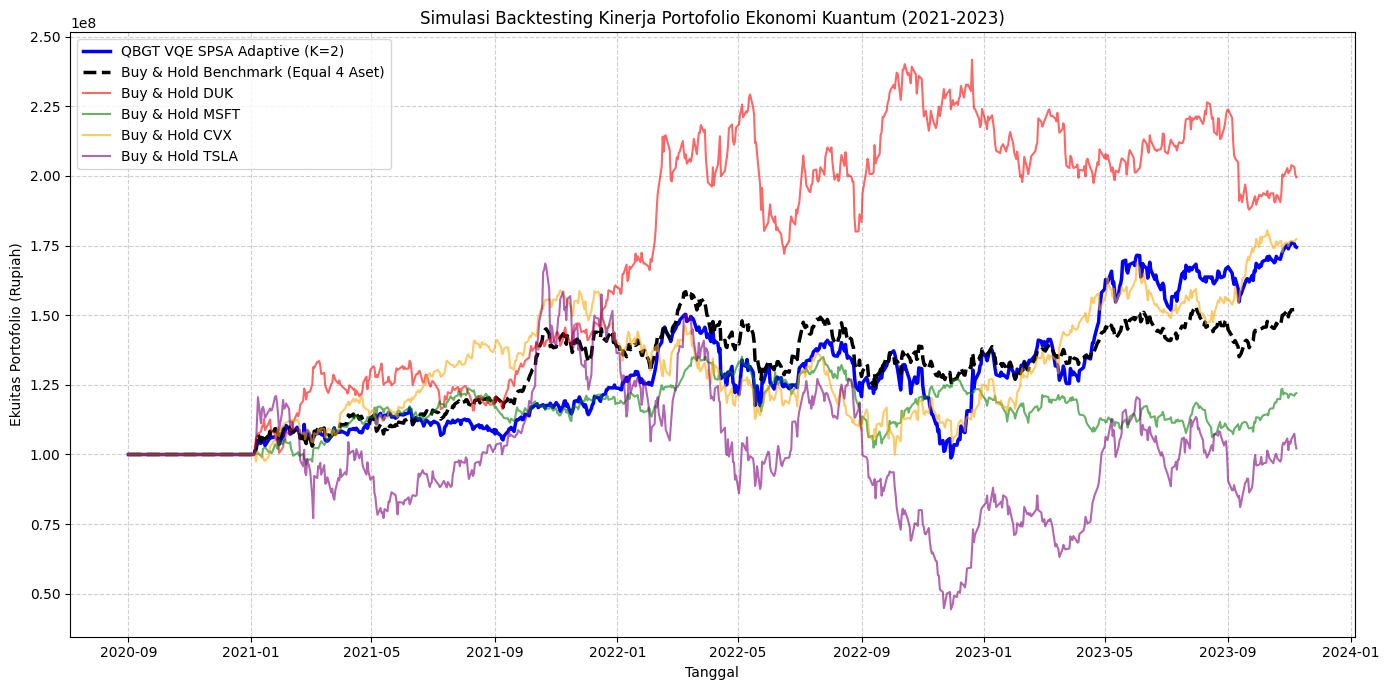

In [9]:
# === VISUALISASI PERTUMBUHAN PORTOFOLIO ===
plt.figure(figsize=(14, 7))

# Plot VQE Strategy
plt.plot(data_clean.index[:len(value_vqe)], value_vqe, label=f'QBGT VQE SPSA Adaptive (K={K})', linewidth=2.5, color='blue')

# Plot Buy & Hold All Equal Weights
plt.plot(data_clean.index[:len(value_bench)], value_bench, label='Buy & Hold Benchmark (Equal 4 Aset)', linewidth=2.5, color='black', linestyle='--')

# Plot Individual Buy & Hold
colors = ['red', 'green', 'orange', 'purple']
for j, t in enumerate(tickers):
    plt.plot(data_clean.index[:len(value_assets[t])], value_assets[t], label=f'Buy & Hold {t}', color=colors[j], alpha=0.6)

plt.title('Simulasi Backtesting Kinerja Portofolio Ekonomi Kuantum (2021-2023)')
plt.ylabel('Ekuitas Portofolio (Rupiah)')
plt.xlabel('Tanggal')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()
